# 캡스톤: 호주 항당뇨제 처방 건수 예측

목표: 1991년부터 2008년까지의 호주 항당뇨제 처방 건수를 예측. 실제 사업에서 이 문제를 해결할 수 있다면 항당뇨제의 생산량을 측정해 수요를 충족하면서도 과잉 생산을 피할 수 있음. 

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/AusAntidiabeticDrug.csv')
df
#204 rows
#y = 월별 처방 건수

,ds,y
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869
...,...,...
199,2008-02-01,21.654285
200,2008-03-01,18.264945
201,2008-04-01,23.107677
202,2008-05-01,22.912510


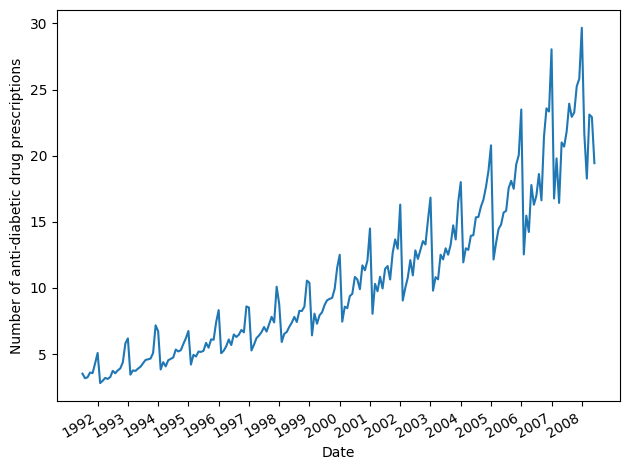

In [ ]:
fig, ax = plt.subplots()

ax.plot(df.y)
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))
#데이터의 row index 6가 1992년의 시작; 203이 마지막;
# 1년은 12개월이므로 12칸 간격으로 선 내놓기

fig.autofmt_xdate()
plt.tight_layout()


도식
- 추세 Trend: 시간의 흐름에 따라 처방 건수가 증가
- 계절성 Seasonality: 매년 낮은 값에서 시작하고 높은 값에서 끝나는 강한 계절성

**어떤 모델이 이 문제를 해결하는 데 가장 적합한지 직관적으로 알 수 있음**

거쳐야 하는 단계:
1) 목표: 12개월 동안의 항당뇨제 처방 건수를 예측. 롤링 예측을 수행할 수 있도록 데이터 집합에서 지난 36개월을 테스트 집합으로 사용.
2) 시계열 시각화.
3) 시계열 분해를 사용해 추세 및 계절적 구성요소를 추출.
4) 탐색을 기반으로 가장 적합한 모델을 결정.
5) 일반적인 단계에 따라 시계열 모델링
    a) 변환을 통해 시계열을 정상적으로
    b) d와 D 값 설정 &  m 값 설정
    c) 최적의 (p,d,q)(P,D,Q)$_m$ 매개변수 탐색
    d) 잔차 분석을 수행해 모델 검증
6) 테스트 집합에 대해 12개월의 롤릴 예측 수행.
7) 예측을 시각화.
8) 모델의 성능을 베이스라인 모델과 비교. 적절한 베이스라인 모델과 오차 지표 선택.
9) 모델을 사용해야 할지에 대해 결론을 내림.



# 시계열 분해 작업

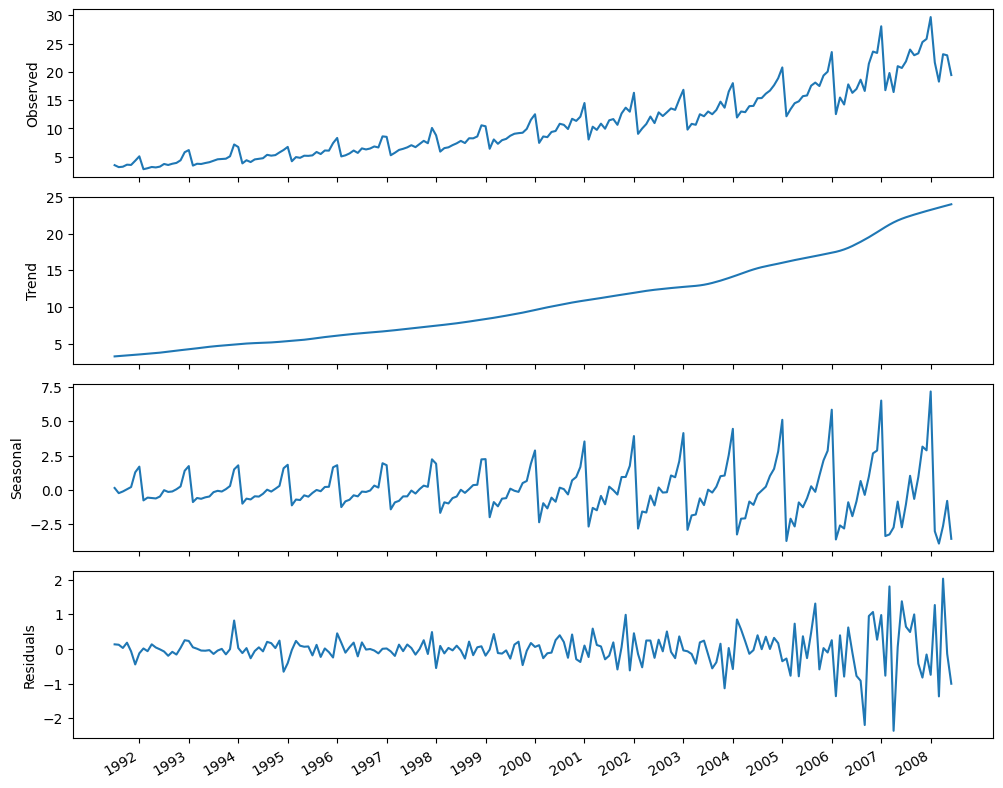

In [6]:
decomp = STL(df.y, period = 12).fit() 
#월별 데이터이니 period = 12

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 4, ncols = 1,
                                         sharex = True, figsize = (10,8))

ax1.plot(decomp.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomp.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomp.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomp.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

fig.autofmt_xdate()
plt.tight_layout()

추세가 있고 계절성이 있음
- SARIMAX(p,d,q)(P,D,Q)$_m$ 최적 모델
- 외생변수는 없으니 SARIMAX 불가.
- 하나의 대상만 예측하고자 하니 VAR 모델도 불가. 

# 정상성 확인

In [7]:
ad_fuller_result = adfuller(df.y)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'ADF P-val: {ad_fuller_result[1]}')

ADF Stats: 3.145185689306745
ADF P-val: 1.0


In [8]:
y_diff = np.diff(df.y, n=1)

ad_fuller_result = adfuller(y_diff)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'ADF P-val: {ad_fuller_result[1]}')

ADF Stats: -2.495172147449745
ADF P-val: 0.1166534168646865


In [9]:
# 데이터에서 강한 계절적 패턴이 있으므로 계절적 차분 적용.
# 월별 데이터이므로 m = 12

y_diff_seasonal_diff = np.diff(y_diff, n = 12)

ad_fuller_result = adfuller(y_diff_seasonal_diff)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'ADF P-val: {ad_fuller_result[1]}')

ADF Stats: -19.848440099535072
ADF P-val: 0.0


주의: 
- 첫번째 차분은 시계열 자체에 대한 차분 --> d = 1
- 두번째 차분은 계절적 차분 --> D = 1 (m = 12)

최종 모델:  
SARIMAX(p,1,q)(P,1,Q)$_{12}$